# **Tugas Besar Data Mining - Part 1**

---

Anggota Kelompok:

-102022400067    Paris

-102022400137    I Putu Gede Aris Pramana

-102022400303    Bravislampa

-102022430039    Muhammad Nur Rizqi

Kelas: SI-48-03

Nama Dosen: Dita Pramesti

---

## Studi Kasus

Dalam studi kasus ini, kita akan melakukan berbagai proses Data Cleansing, Data Reduction, Missing Value Handling, dan Data Transformation pada dataset yang berkaitan dengan kendaraan BMW. Dataset ini terdiri dari informasi mengenai berbagai model BMW dengan detail spesifikasi, harga, performa, dan kondisi kendaraan dari berbagai tahun. Data ini mengumpulkan informasi tentang karakteristik teknis dan ekonomis dari kendaraan BMW yang tersedia di pasaran.

### 📄 Informasi Dataset

Dataset ini terdiri dari data kendaraan BMW dengan fitur-fitur yang menjelaskan karakteristik setiap unit kendaraan. Dataset mencakup informasi berikut:

1. **model**: Model kendaraan BMW (contoh: 5 Series, 6 Series, 1 Series, 2 Series, 3 Series, 4 Series, 7 Series, X3, dll).
2. **year**: Tahun pembuatan kendaraan (berkisar dari berbagai tahun).
3. **price**: Harga kendaraan dalam mata uang tertentu.
4. **transmission**: Jenis transmisi kendaraan (Automatic atau Manual).
5. **mileage**: Jarak tempuh kendaraan dalam mil atau kilometer.
6. **fuelType**: Jenis bahan bakar yang digunakan (Diesel, Petrol, atau Other).
7. **tax**: Jumlah pajak kendaraan tahunan.
8. **mpg**: Efisiensi bahan bakar dalam miles per gallon (MPG) - seberapa jauh kendaraan dapat menempuh perjalanan dengan satu satuan bahan bakar.
9. **engineSize**: Ukuran mesin kendaraan dalam liter - mengindikasikan kapasitas dan daya mesin.

---

### Library

Harap untuk diperhatikan, jika library terjadi error ataupun sejenisnya. Silahkan jalankan kode dibawah ini dengan menghapus tanda '#'.

In [1]:
# Jika belum punya library python dibawah ini, silahkan jalankan code dibawah ini
%pip install "pandas>=2.0.0" "numpy>=1.24.0" "scikit-learn>=1.2.2" "matplotlib>=3.7.1" "seaborn>=0.12.2"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## **Read Data**

Pertama, kita akan membaca dataset menggunakan library pandas dan menampilkan beberapa baris awal untuk memahami struktur data.

In [3]:
import pandas as pd
df = pd.read_csv('bmw.csv')

## **Data Cleansing**

### Duplikasi data

Selanjutnya, kita akan melakukan pengecekan apakah ada data yang duplikat dalam dataset. 

Jika ada data yang duplikat, kita menghapusnya karena data duplikat dapat mempengaruhi hasil analisis.

Cek data duplikasi

In [3]:
df.info()
duplicated =df.duplicated().sum()
print("Jumlah duplikat yang ditemukan:\n", duplicated)

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  str    
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  str    
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  str    
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 758.2 KB
Jumlah duplikat yang ditemukan:
 117


Drop duplikasi data

In [4]:
df_cleaned = df.drop_duplicates()

Tampilkan Keseluruhan data untuk dicek

In [7]:
print(f"Jumlah baris sebelum drop duplikat: {len(df)}")
print(f"Jumlah baris setelah drop duplikat: {len(df_cleaned)}")
print(f"Jumlah baris yang dihapus: {len(df) - len(df_cleaned)}")
info = df_cleaned.info()

Jumlah baris sebelum drop duplikat: 10781
Jumlah baris setelah drop duplikat: 10664
Jumlah baris yang dihapus: 117
<class 'pandas.DataFrame'>
Index: 10664 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10664 non-null  str    
 1   year          10664 non-null  int64  
 2   price         10664 non-null  int64  
 3   transmission  10664 non-null  str    
 4   mileage       10664 non-null  int64  
 5   fuelType      10664 non-null  str    
 6   tax           10664 non-null  int64  
 7   mpg           10664 non-null  float64
 8   engineSize    10664 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 833.1 KB


### Data Null

Periksa apakah ada kolom yabg memiliki nilai yang hilang (missing values). Kita menghapus baris-baris yang mengandung nilai kosong, karena bisa memengaruhi kualitas model jika tidak ditangani.

Melihat info dari data

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  str    
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  str    
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  str    
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 758.2 KB


Cek total nilai null didalam tiap kolom

In [ ]:
print(df.isnull().sum())

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


Karena setelah diperiksa data sudah baik tanpa adanya kondisi null maka tidak perlu lagi untuk dihapus

Cek hasil drop nilai null

In [12]:
print(df.isnull().sum())
print(f"\nTotal baris setelah drop nilai null: {len(df)}")

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Total baris setelah drop nilai null: 10781


### Drop kolom yang tidak di butuhkan

Periksan apakah ada kolom yang tidak relevan dengan analisis yang ingin kita lakukan

In [13]:
print(df.isnull().sum())

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


Cek Info data

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  str    
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  str    
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  str    
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 758.2 KB


Drop kolom yang tidak di butuhkan kolum: **'model', 'engineSize', 'tax', 'transmission', 'fueltype'**.

-model karena memiliki kardinalitas tinggi,

-engineSize karena sangat berkaitan dengan mpg karena membuat algoritma tidak stabil

-Transmission membuat hasil pengelompokan menjadi bias dan tidak valid.

-fueltype: membuat algoritma berjalan jauh lebih optimal dan akurat.

-Tax: Besaran pajak mobil biasanya tidak ditentukan secara acak, melainkan dihitung berdasarkan emisi gas buang (yang sangat berkorelasi dengan mpg), kapasitas mesin (engineSize), dan umur kendaraan (year). Artinya, informasi yang dibawa oleh tax sebenarnya sudah diwakili oleh ketiga variabel: tersebut.

In [4]:
df = df.drop(columns=['model', 'engineSize', 'transmission', 'fuelType', 'tax'])

Cek Info data

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     10781 non-null  int64  
 1   price    10781 non-null  int64  
 2   mileage  10781 non-null  int64  
 3   mpg      10781 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 337.0 KB


## **Missing Value Handling**

### Fill Missing Values by Mean

Karena tidak ada "Missing value" maka dibagian ini dapat kita lewati

Cek total nilai null pada tiap kolom

In [6]:
missingvalue = df.isnull()
print(missingvalue)

        year  price  mileage    mpg
0      False  False    False  False
1      False  False    False  False
2      False  False    False  False
3      False  False    False  False
4      False  False    False  False
...      ...    ...      ...    ...
10776  False  False    False  False
10777  False  False    False  False
10778  False  False    False  False
10779  False  False    False  False
10780  False  False    False  False

[10781 rows x 4 columns]


Buatlah grafik histogram pada semua kolom menggunakan matplotlib

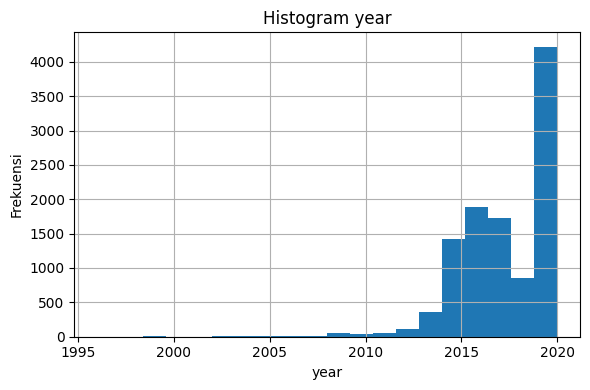

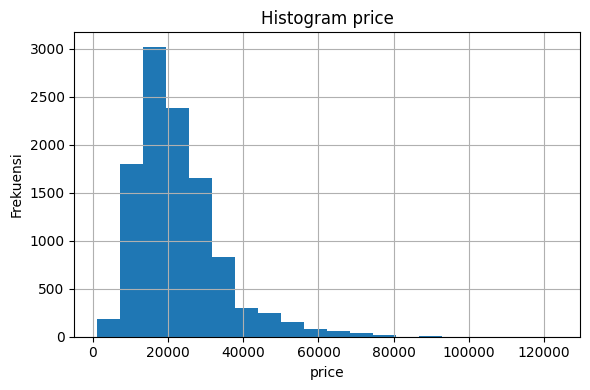

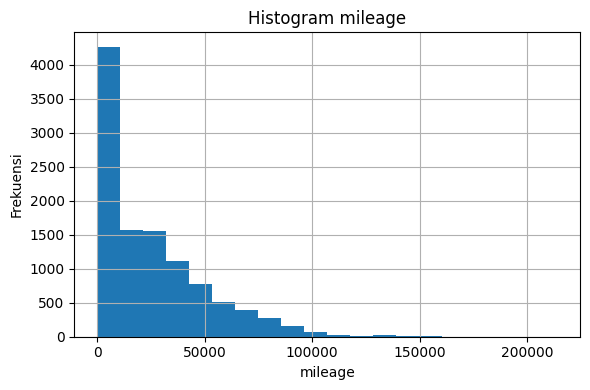

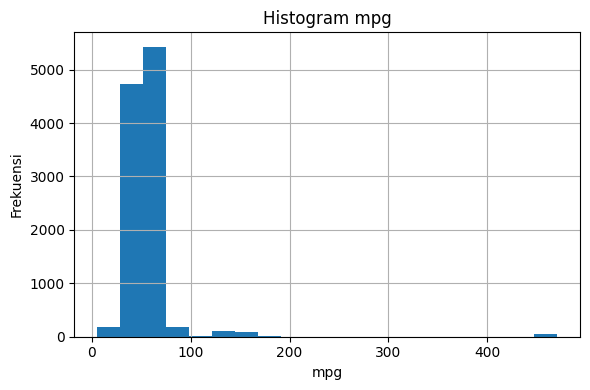

In [7]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=['number']).columns
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=20)
    plt.title(f'Histogram {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.tight_layout()
    plt.show()

Isi nilai null pada kolom dengan nilai mean. tidak ada "Missing value"

Cek total nilai null pada tiap kolom

In [9]:
print('Total nilai null pada kolom mean setelah imputasi:')
print(df.isnull().sum())

Total nilai null pada kolom mean setelah imputasi:
year       0
price      0
mileage    0
mpg        0
dtype: int64


Cek 10 data teratas

In [10]:
df.head(10)

,year,price,mileage,mpg
0,2014,11200,67068,57.6
1,2018,27000,14827,42.8
2,2016,16000,62794,51.4
3,2017,12750,26676,72.4
4,2014,14500,39554,50.4
5,2016,14900,35309,60.1
6,2017,16000,38538,60.1
7,2018,16250,10401,52.3
8,2017,14250,42668,62.8
9,2016,14250,36099,68.9


### Fill Missing Values by Median

jika ada nilai yang hilang, kita mengisi dengan median karena median mempresentasikan nilai tengah dari masing masing kolom dan cocok untuk kurva yang miring atau skewed.

Cek total nilai null pada tiap kolom

In [11]:
print('Total nilai null di setiap kolom untuk median:')
print(df.isnull().sum())

Total nilai null di setiap kolom untuk median:
year       0
price      0
mileage    0
mpg        0
dtype: int64


Isi nilai null pada kolom dengan nilai Median. tidak ada "Missing value"

Cek total nilai null pada tiap kolom

In [14]:
print('\nTotal nilai null di seluruh dataframe:')
print(df.isnull().sum())


Total nilai null di seluruh dataframe:
year       0
price      0
mileage    0
mpg        0
dtype: int64


Tampilkan 10 data teratas

In [15]:
df.head(10)

,year,price,mileage,mpg
0,2014,11200,67068,57.6
1,2018,27000,14827,42.8
2,2016,16000,62794,51.4
3,2017,12750,26676,72.4
4,2014,14500,39554,50.4
5,2016,14900,35309,60.1
6,2017,16000,38538,60.1
7,2018,16250,10401,52.3
8,2017,14250,42668,62.8
9,2016,14250,36099,68.9


## Outliers Handling

Outlier adalah data yang tidak lazim atau sangat berbeda dari data lainnya. Pada kasus ini, kita akan mendeteksi outlier pada semua kolom menggunakan metode Interquartile Range (IQR), dan menghapus data yang berada di luar batas.

Tampilkan ringkasan statistik dari data

In [16]:
df.describe()

,year,price,mileage,mpg
count,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,56.399035
std,2.349038,11415.528189,25143.192559,31.336958
min,1996.000000,1200.000000,1.000000,5.500000
25%,2016.000000,14950.000000,5529.000000,45.600000
50%,2017.000000,20462.000000,18347.000000,53.300000
75%,2019.000000,27940.000000,38206.000000,62.800000
max,2020.000000,123456.000000,214000.000000,470.800000


Buat grafik Boxplot semua colums Outlier menggunakan library matplotlib dan pandas

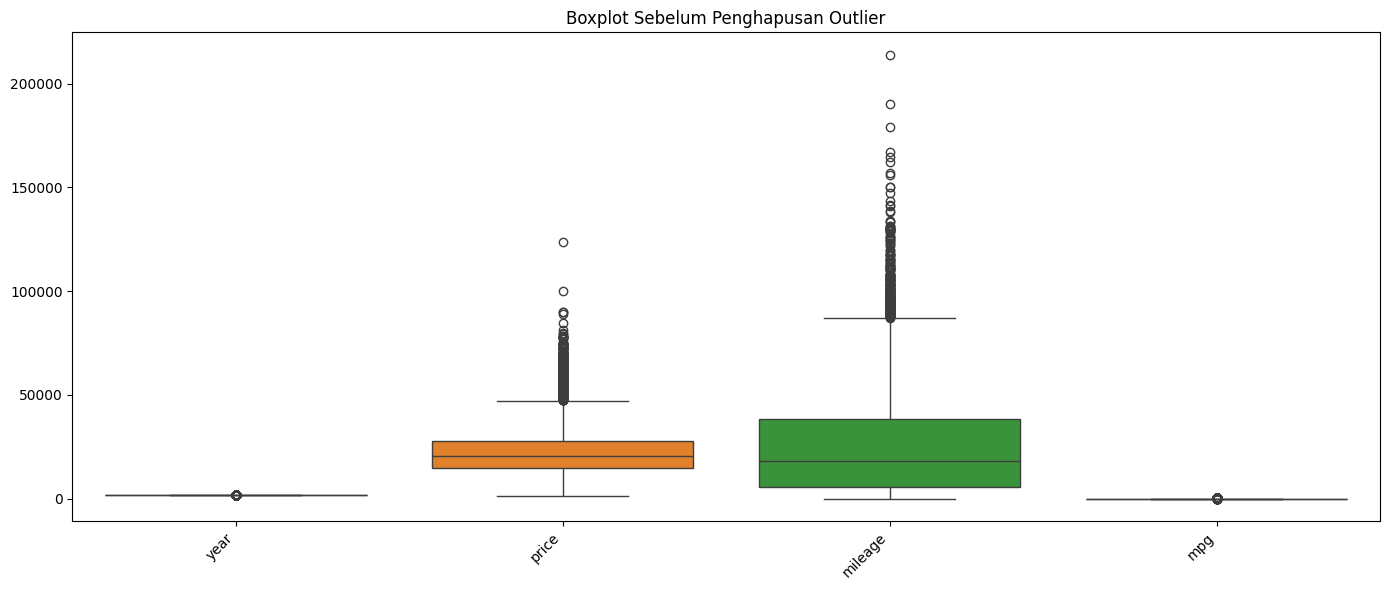

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns[:6]
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45, ha='right')
plt.title('Boxplot Sebelum Penghapusan Outlier')
plt.tight_layout()
plt.show()

Drop Data yang outlier

In [18]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_cleaned_outliers = df.copy()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned_outliers = df_cleaned_outliers[(df_cleaned_outliers[col] >= lower_bound) & (df_cleaned_outliers[col] <= upper_bound)]

Print total baris sebelum outlier dihapus dan sesudah dihapus. Serta inisiasikan variabel data yang telah bersih ke dalam df kembali (df = variabel data yang telah bersih)

In [19]:
print(f"Total baris sebelum drop outlier: {len(df)}")
print(f"Total baris setelah drop outlier: {len(df_cleaned_outliers)}")
print(f"Jumlah baris yang dihapus: {len(df) - len(df_cleaned_outliers)}")

# Update df dengan data yang sudah bersih
df = df_cleaned_outliers

Total baris sebelum drop outlier: 10781
Total baris setelah drop outlier: 9633
Jumlah baris yang dihapus: 1148


Buat grafik Boxplot semua colums setelah pembersihan Outlier

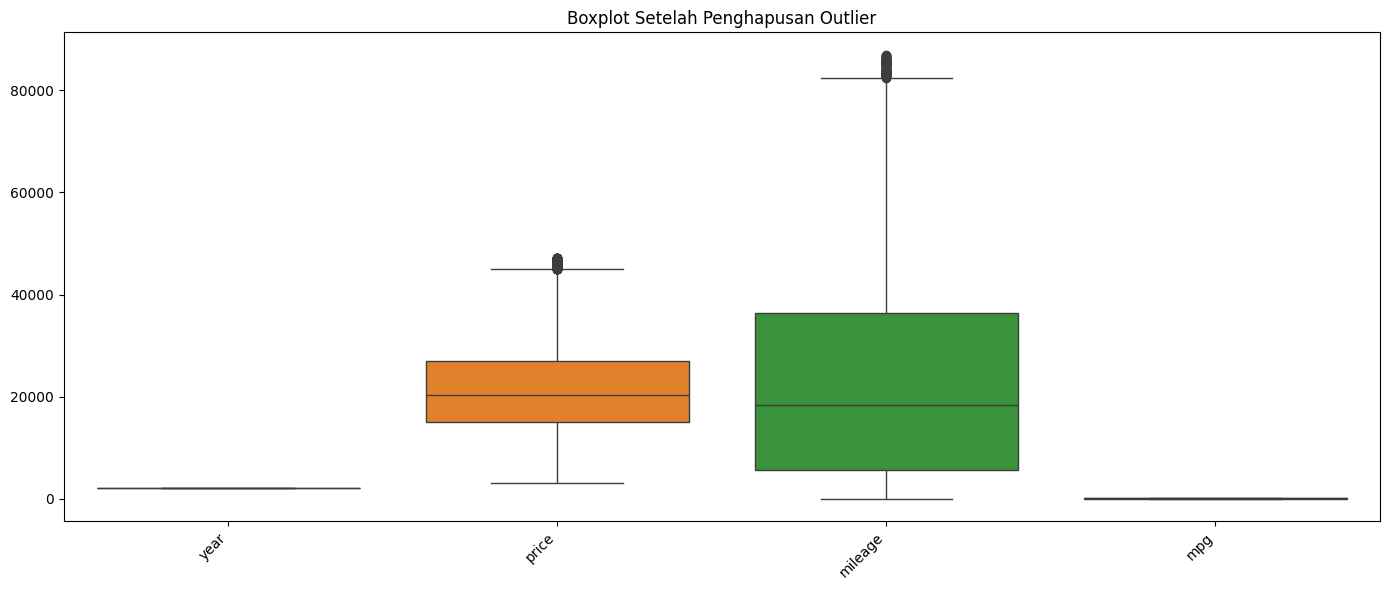

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns[:6]  # First 6 numeric columns
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45, ha='right')
plt.title('Boxplot Setelah Penghapusan Outlier')
plt.tight_layout()
plt.show()

Cek info data

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 9633 entries, 0 to 10780
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     9633 non-null   int64  
 1   price    9633 non-null   int64  
 2   mileage  9633 non-null   int64  
 3   mpg      9633 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 376.3 KB


## **Data Reduction**

### PCA

PCA digunakan untuk mengurangi dimensi data tanpa kehilangan terlalu banyak informasi. Dalam kasus ini, kita menggunakan PCA untuk mengekstrak dua komponen utama dari data yang telah dinormalisasi.

Library yang digunakan: **sklearn.decomposition (PCA), numpy, sklearn.preprocessing (StandardScaler)**

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

memilih kolom numerik yang ingin di gunakan

-
-

In [1]:
# filepath: c:\Perkuliahan\Semester 4\PENAMBANGAN DATA SI\Tubes\TUBES DATMIN - Part 1 (fixed).ipynb
# Pilih kolom numerik untuk PCA
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("Kolom numerik yang digunakan:", numeric_cols.tolist())
print(f"\nJumlah fitur sebelum PCA: {len(numeric_cols)}")

# Simpan data sebelum PCA
df_before_pca = df[numeric_cols].head()
print("\nData sebelum PCA:")
print(df_before_pca)

NameError: name 'df' is not defined

Lakukan normalisasi data dengan StandardScaler

In [ ]:
# filepath: c:\Perkuliahan\Semester 4\PENAMBANGAN DATA SI\Tubes\TUBES DATMIN - Part 1 (fixed).ipynb
# Normalisasi data dengan StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[numeric_cols])
print("Data setelah dinormalisasi (5 baris pertama):")
print(pd.DataFrame(df_scaled, columns=numeric_cols).head())

Menerapkan PCA untuk mengurangi dimensi dari 12 dimensi menjadi 2

In [ ]:
# filepath: c:\Perkuliahan\Semester 4\PENAMBANGAN DATA SI\Tubes\TUBES DATMIN - Part 1 (fixed).ipynb
# Terapkan PCA - mengurangi dimensi menjadi 2 komponen utama
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Buat dataframe hasil PCA
df_pca_result = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
print("Data setelah PCA (5 baris pertama):")
print(df_pca_result.head())

# Tampilkan informasi variance
print(f"\nVariance explained oleh PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Variance explained oleh PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

Tampilkan 5 data sebelum dan data setelah pengimplementasian PCA

In [ ]:
# filepath: c:\Perkuliahan\Semester 4\PENAMBANGAN DATA SI\Tubes\TUBES DATMIN - Part 1 (fixed).ipynb
# Tampilkan perbandingan data sebelum dan setelah PCA
print("=== Data Sebelum PCA ===")
print(df_before_pca)
print("\n=== Data Setelah PCA ===")
print(df_pca_result.head())

# Simpan hasil PCA ke variabel df (sesuai instruksi di referensi)
# df_4NIM TERAKHIR = df_PCA (menggunakan 2 digit terakhir NIM: 67)
df_0067 = df_pca_result
print(f"\nData reduction result saved as: df_0067")
print(f"Jumlah fitur setelah PCA: {df_0067.shape[1]} (berdasarkan 2 komponen utama)")

## **Data Transformation**

### Normalization (Min-Max Scaling)

Kita menerapkan normalisasi sehingga nilainya berada di rentang 0 hingga 1. Ini penting dalam banyak model machine learning yang sensitif terhadap skala data.

Melihat data teratas

In [26]:
print(df.head())

       model  year  price transmission  mileage fuelType  tax   mpg  \
0   5 Series  2014  11200    Automatic    67068   Diesel  125  57.6   
1   6 Series  2018  27000    Automatic    14827   Petrol  145  42.8   
2   5 Series  2016  16000    Automatic    62794   Diesel  160  51.4   
3   1 Series  2017  12750    Automatic    26676   Diesel  145  72.4   
4   7 Series  2014  14500    Automatic    39554   Diesel  160  50.4   

   engineSize  
0         2.0  
1         2.0  
2         3.0  
3         1.5  
4         3.0  


Import library

**sklearn.preprocessing (MinMaxScaler)**

In [78]:
from sklearn.preprocessing import MinMaxScaler

Normalisasikan data

### Discretization (Binning)

Kolom seperti **price** dibagi menjadi beberapa kategori (Rendah, Sedang, Tinggi) untuk tujuan klasifikasi.

Tampilkan data teratas

Lakukan labeling dengan bins = 3 dan label berupa Rendah, Sedang, Tinggi

Tampilkan data teratas

### One-Hot Encoding

Kolom kategori seperti **group** yang telah dibuat sebelumnya diubah menjadi format numerik menggunakan One-Hot Encoding. Ini membantu model machine learning untuk memahami variabel kategori.

Berikan kesimpulan yang mencakup semua proses yang telah dilakukan